# **Task 3: Heart Disease Prediction**

**Problem Statement**:
The objective of this task is to build a classification model that can predict whether an individual is at risk of heart disease based on their health data.

**Goal**:
This involves cleaning the dataset, performing exploratory data analysis (EDA), training and evaluating a classification model (Logistic Regression or Decision Tree), and identifying important features contributing to the prediction.

- ## **Dataset Loading and Preprocessing**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, roc_auc_score, ConfusionMatrixDisplay

In [2]:
df = pd.read_csv('/content/heart_disease_uci.csv')
display(df.head())

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


- ## **Data Visualization and Exploration (EDA)**

In [3]:
df.shape

(920, 16)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


In [5]:
df.describe()

,id,age,trestbps,chol,thalch,oldpeak,ca,num
count,920.000000,920.000000,861.000000,890.000000,865.000000,858.000000,309.000000,920.000000
mean,460.500000,53.510870,132.132404,199.130337,137.545665,0.878788,0.676375,0.995652
std,265.725422,9.424685,19.066070,110.780810,25.926276,1.091226,0.935653,1.142693
min,1.000000,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000
25%,230.750000,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000,0.000000
50%,460.500000,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000
75%,690.250000,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000,2.000000
max,920.000000,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,4.000000


- ## **Check for Missing Values**

In [6]:
df.isnull().sum()

,0
id,0
age,0
sex,0
dataset,0
cp,0
trestbps,59
chol,30
fbs,90
restecg,2
thalch,55


- ## **Data Cleaning and Preprocessing**


### 1. Drop id and dataset columns

In [7]:
df = df.drop(['id', 'dataset'], axis=1)
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,63,Male,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,67,Male,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,67,Male,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,37,Male,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,41,Female,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


### 2. Convert num to Binary Target Variable


In [8]:
df['target'] = df['num'].apply(lambda x: 1 if x > 0 else 0)
df = df.drop('num', axis=1)
df['target'].value_counts()

,count
target,
1,509
0,411


### 3. Handle Missing Numerical Values (Imputation with Median)



In [9]:
numerical_cols_with_missing = ['trestbps', 'chol', 'thalch', 'oldpeak']

for col in numerical_cols_with_missing:
    median_val = df[col].median()
    df[col].fillna(median_val, inplace=True)

df[numerical_cols_with_missing].isnull().sum()

/tmp/ipykernel_17113/62133940.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(median_val, inplace=True)


,0
trestbps,0
chol,0
thalch,0
oldpeak,0


### 4. Handle Missing Categorical Values (Imputation with Mode)


In [10]:
df['ca'] = df['ca'].replace('?', pd.NA).astype(object)
df['thal'] = df['thal'].replace('?', pd.NA).astype(object)

categorical_cols_with_missing = ['fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

for col in categorical_cols_with_missing:
    mode_val = df[col].mode()[0]  # mode() can return multiple values, pick the first
    df[col].fillna(mode_val, inplace=True)

df[categorical_cols_with_missing].isnull().sum()

/tmp/ipykernel_17113/2077361841.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(mode_val, inplace=True)
/tmp/ipykernel_17113/2077361841.py:8: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col].fillna(mode_val, inplace=True)


,0
fbs,0
restecg,0
exang,0
slope,0
ca,0
thal,0


### 5. One-Hot Encode Categorical Features


In [11]:
# Perform one-hot encoding
categorical_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
df.head()

,age,trestbps,chol,thalch,oldpeak,target,sex_Male,cp_atypical angina,cp_non-anginal,cp_typical angina,...,restecg_normal,restecg_st-t abnormality,exang_True,slope_flat,slope_upsloping,ca_1.0,ca_2.0,ca_3.0,thal_normal,thal_reversable defect
0,63,145.0,233.0,150.0,2.3,0,True,False,False,True,...,False,False,False,False,False,False,False,False,False,False
1,67,160.0,286.0,108.0,1.5,1,True,False,False,False,...,False,False,True,True,False,False,False,True,True,False
2,67,120.0,229.0,129.0,2.6,1,True,False,False,False,...,False,False,True,True,False,False,True,False,False,True
3,37,130.0,250.0,187.0,3.5,0,True,False,True,False,...,True,False,False,False,False,False,False,False,True,False
4,41,130.0,204.0,172.0,1.4,0,False,True,False,False,...,False,False,False,False,True,False,False,False,True,False


- ## **Model Training and Evaluation**


### 1. Do Train, Test and Split


In [12]:
X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (736, 20)
X_test shape: (184, 20)
y_train shape: (736,)
y_test shape: (184,)


### 2. Train Logistic Regression Model


In [13]:
# Initialize and train the Logistic Regression model
log_reg_model = LogisticRegression(random_state=42, solver='liblinear')
log_reg_model.fit(X_train, y_train)

LogisticRegression(random_state=42, solver='liblinear')

### 3. Model Evaluation (Logistic Regression)


In [14]:
# Make predictions on the test set
y_pred_log_reg = log_reg_model.predict(X_test)
y_proba_log_reg = log_reg_model.predict_proba(X_test)[:, 1]

In [15]:
# Accuracy
accuracy_log_reg = accuracy_score(y_test, y_pred_log_reg)
accuracy_log_reg

0.842391304347826

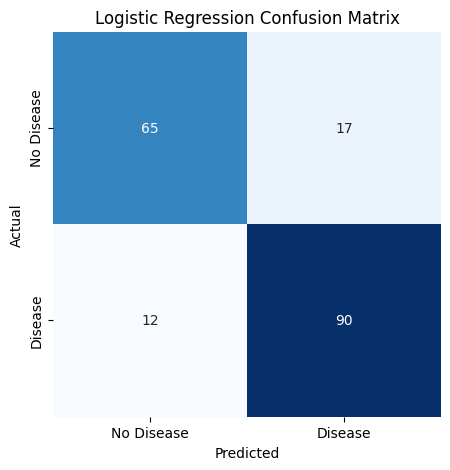

In [16]:
# Confusion Matrix
cm_log_reg = confusion_matrix(y_test, y_pred_log_reg)
plt.figure(figsize=(5, 5))
sns.heatmap(cm_log_reg, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['No Disease', 'Disease'], yticklabels=['No Disease', 'Disease'])
plt.title('Logistic Regression Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

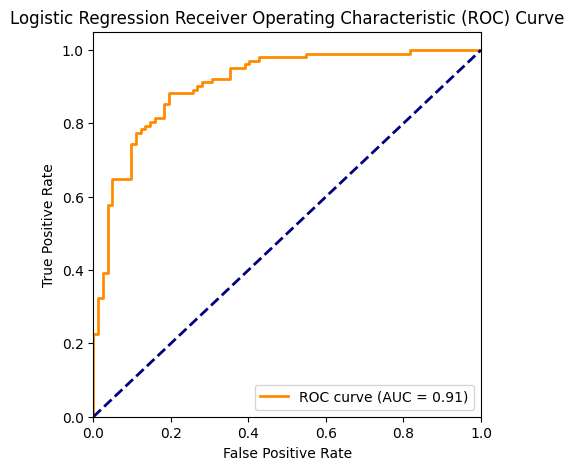

In [17]:
# ROC Curve
fpr_log_reg, tpr_log_reg, thresholds_log_reg = roc_curve(y_test, y_proba_log_reg)
auc_log_reg = roc_auc_score(y_test, y_proba_log_reg)

plt.figure(figsize=(5, 5))
plt.plot(fpr_log_reg, tpr_log_reg, color='darkorange', lw=2, label=f'ROC curve (AUC = {auc_log_reg:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Logistic Regression Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

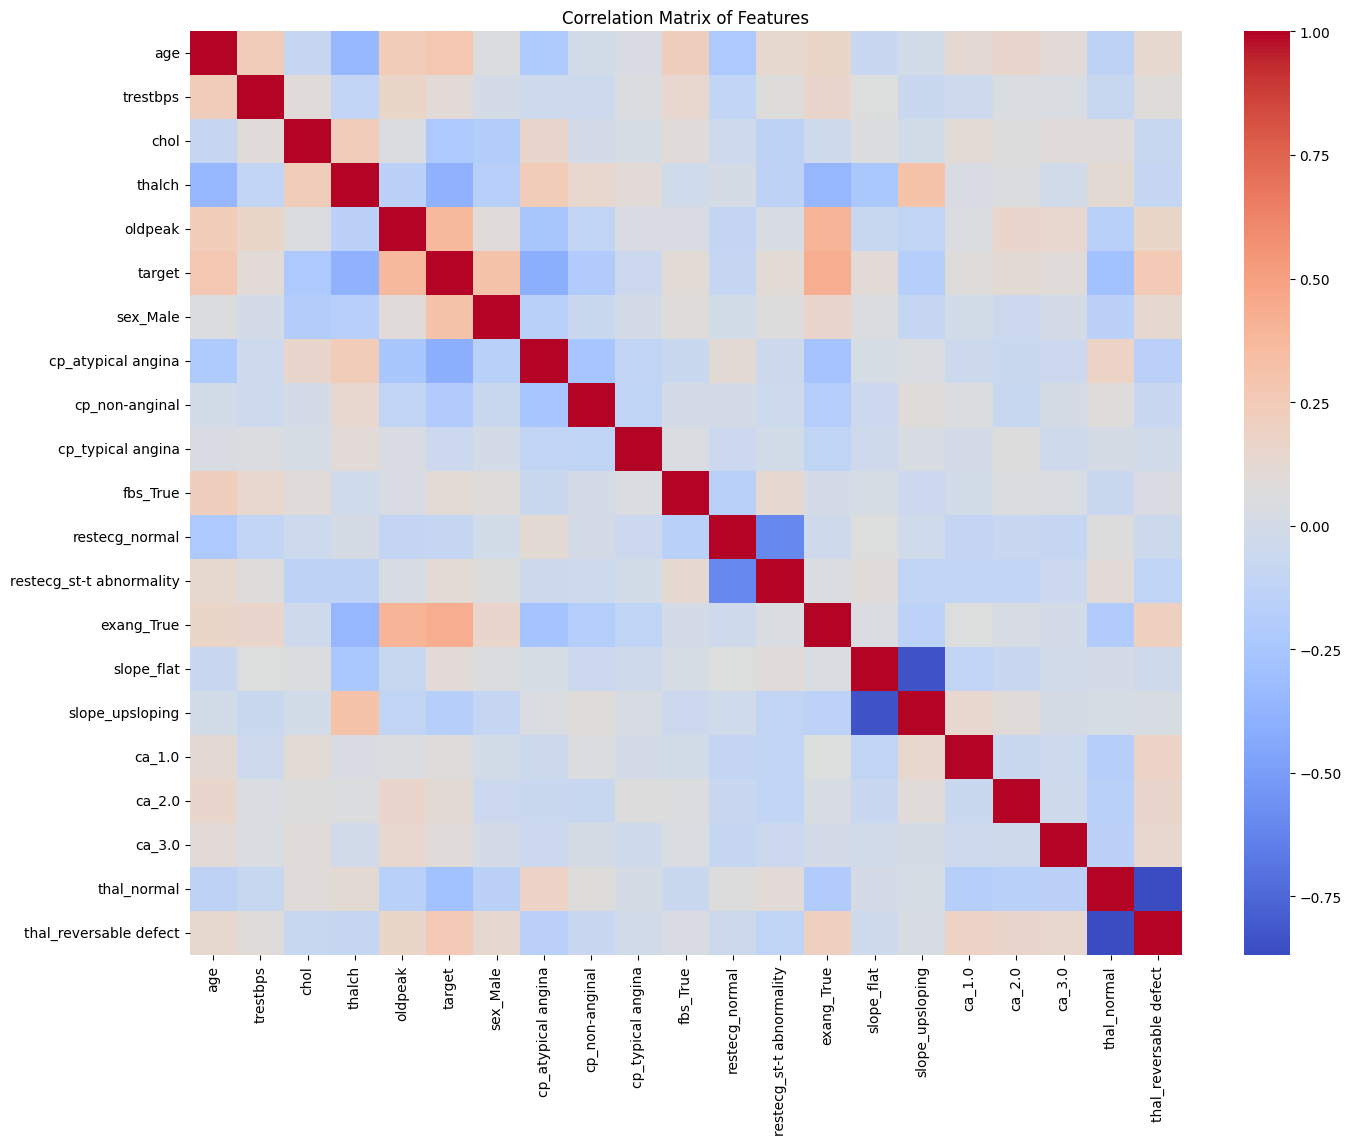

In [18]:
# Correlation Matrix
plt.figure(figsize=(16, 12))
sns.heatmap(df.corr(numeric_only=True), annot=False, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Features')
plt.show()

- ## **Highlighting important features affecting prediction. (Logistic Regression)**

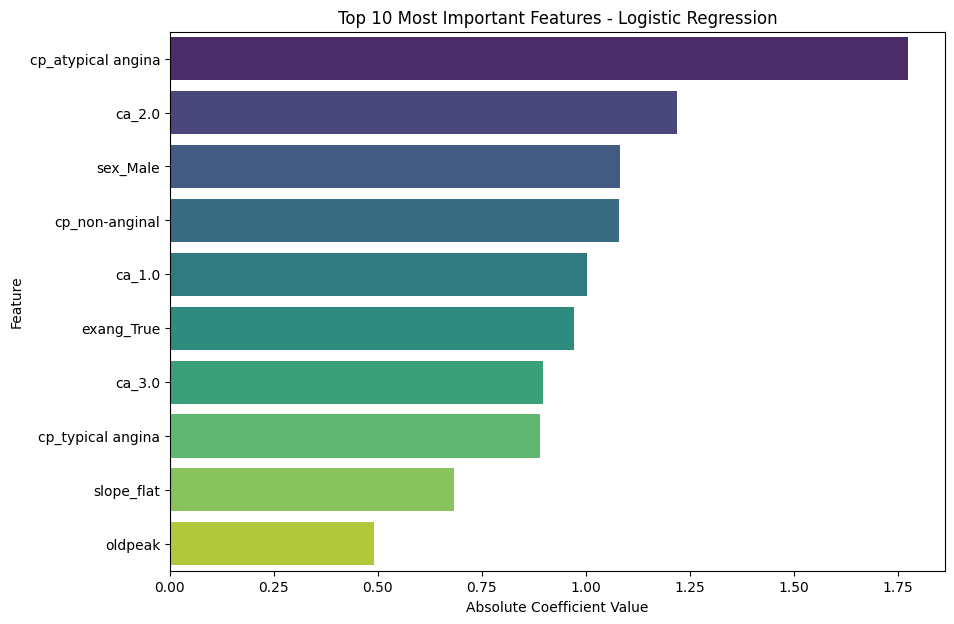

In [19]:
# Get coefficients and feature names
coefficients = log_reg_model.coef_[0]
feature_names = X.columns

# Create a DataFrame for feature importance
feature_importance_log_reg = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefficients})
feature_importance_log_reg['Abs_Coefficient'] = np.abs(feature_importance_log_reg['Coefficient'])
feature_importance_log_reg = feature_importance_log_reg.sort_values(by='Abs_Coefficient', ascending=False)

plt.figure(figsize=(10, 7))
sns.barplot(x='Abs_Coefficient', y='Feature', data=feature_importance_log_reg.head(10), palette='viridis', hue='Feature', legend=False)
plt.title('Top 10 Most Important Features - Logistic Regression')
plt.xlabel('Absolute Coefficient Value')
plt.ylabel('Feature')
plt.show()